In [70]:
# ── Imports ───────────────────────────────────────────────────
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    pipeline
)

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.makedirs("../results/figures/shap", exist_ok=True)
os.makedirs("../results/metrics",      exist_ok=True)




In [71]:
# Use mBERT (your best performing model)
MODEL_PATH = "../models/transformers/mBERT_finetuned"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)
model.eval()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model = model.to(DEVICE)
print(f"✅ Model loaded on {DEVICE}")

Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 2821.55it/s]


✅ Model loaded on cuda


In [72]:
def predict_proba(texts):
    """
    Handles both plain strings and
    SHAP masked numpy arrays
    """
    # ── Fix input type ────────────────────────────────────────
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    if isinstance(texts, str):
        texts = [texts]

    # Convert any non-string elements to string
    texts = [
        str(t) if not isinstance(t, str) else t
        for t in texts
    ]

    # Remove empty strings
    texts = [t if t.strip() else "[UNK]" for t in texts]

    all_probs = []
    batch_size = 8

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors = "pt",
            truncation     = True,
            padding        = True,
            max_length     = 128
        )
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits, dim=1
        ).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)

# ── Test fixed function ───────────────────────────────────────
test_texts = [
    "Absolutely amazing product! Best purchase ever!!!",
    "khana ekdum mito thiyo, feri aaunchu pakkai",
]
probs = predict_proba(test_texts)
print("✅ predict_proba works!")
for text, prob in zip(test_texts, probs):
    label = "FAKE" if prob[1] > 0.5 else "GENUINE"
    print(f"  {label} ({prob[0]:.3f} genuine / "
          f"{prob[1]:.3f} fake)")
    print(f"  → {text[:60]}")

✅ predict_proba works!
  FAKE (0.000 genuine / 1.000 fake)
  → Absolutely amazing product! Best purchase ever!!!
  GENUINE (1.000 genuine / 0.000 fake)
  → khana ekdum mito thiyo, feri aaunchu pakkai


In [74]:
# Use pipeline-based explainer instead
# More stable with transformers

pipe = pipeline(
    "text-classification",
    model     = model,
    tokenizer = tokenizer,
    device    = 0 if torch.cuda.is_available() else -1,
    top_k     = None,        # return all class scores
)

def pipeline_predict(texts):
    """Pipeline-based predict for SHAP"""
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()
    if isinstance(texts, str):
        texts = [texts]
    texts = [
        str(t) if not isinstance(t, str) else t
        for t in texts
    ]
    texts = [t if t.strip() else "[UNK]" for t in texts]

    results = pipe(texts)
    probs   = []
    for result in results:
        # Sort by label to ensure consistent order
        sorted_result = sorted(result, key=lambda x: x["label"])
        probs.append([r["score"] for r in sorted_result])
    return np.array(probs)

# ── Recreate explainer with fixed function ────────────────────
masker    = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(
    pipeline_predict,
    masker,
    # output_names=["LABEL_0", "LABEL_1"]  # genuine, fake
    output_names=["genuine", "fake"] 
)

print("✅ Explainer recreated!")

# ── Test explainer on one sample ──────────────────────────────
test_val = pipeline_predict([
    "Absolutely amazing! Best product ever!!!",
    "ramro thiyo khana, feri aaunchu"
])
print(f"Test probabilities shape : {test_val.shape}")
print(f"Sample 1 : genuine={test_val[0][0]:.3f} "
      f"fake={test_val[0][1]:.3f}")
print(f"Sample 2 : genuine={test_val[1][0]:.3f} "
      f"fake={test_val[1][1]:.3f}")

✅ Explainer recreated!
Test probabilities shape : (2, 2)
Sample 1 : genuine=0.003 fake=0.997
Sample 2 : genuine=1.000 fake=0.000


In [75]:
# Check what labels pipeline returns
test_result = pipe(["test review"])
print("Pipeline output:")
print(test_result)

Pipeline output:
[[{'label': 'LABEL_0', 'score': 0.9999696016311646}, {'label': 'LABEL_1', 'score': 3.044846380362287e-05}]]


In [76]:
# ══════════════════════════════════════════════════════════════
# PREPARE SAMPLES
# ══════════════════════════════════════════════════════════════
# Manually crafted samples covering all scenarios:
# - obvious fake / genuine
# - ambiguous code-mixed
# - each language style

samples = [
    # ── Obvious Fake (English) ────────────────────────────────
    {
        "text":  "ABSOLUTELY AMAZING!!! Best product ever! "
                 "Life changing! Highly recommend to everyone!!!",
        "label": 1,
        "lang":  "english",
        "type":  "obvious_fake"
    },
    {
        "text":  "TOTAL WASTE of money! Worst experience ever! "
                 "Never coming back! Criminal fraud company!!!",
        "label": 1,
        "lang":  "english",
        "type":  "obvious_fake_negative"
    },

    # ── Obvious Genuine (Nepali) ──────────────────────────────
    {
        "text":  "khana thikai thiyo, dherai expensive lagyo "
                 "tara atmosphere ramro cha, feri aaunchu",
        "label": 0,
        "lang":  "romanized_nepali",
        "type":  "obvious_genuine"
    },
    {
        "text":  "service slow thiyo, 30 min wait gardinu "
                 "paryo tara food quality okay cha bro",
        "label": 0,
        "lang":  "romanized_nepali",
        "type":  "obvious_genuine"
    },

    # ── Ambiguous Code-mixed ──────────────────────────────────
    {
        "text":  "ekdum best place, ramro service, "
                 "highly recommend everyone lai",
        "label": 1,
        "lang":  "code_mixed",
        "type":  "ambiguous_fake"
    },
    {
        "text":  "dherai ramro thiyo, best experience ever, "
                 "paisa vasool cha definitely",
        "label": 1,
        "lang":  "code_mixed",
        "type":  "ambiguous_fake"
    },
    {
        "text":  "service okay cha, food mito thiyo tara "
                 "bit expensive, overall thikai",
        "label": 0,
        "lang":  "code_mixed",
        "type":  "ambiguous_genuine"
    },
    {
        "text":  "driver late aayo, tara ride comfortable "
                 "thiyo, app use garna sajilo cha",
        "label": 0,
        "lang":  "code_mixed",
        "type":  "ambiguous_genuine"
    },

    # ── Genuine English ───────────────────────────────────────
    {
        "text":  "service was okay, waited long but food "
                 "came eventually, not perfect but works",
        "label": 0,
        "lang":  "english",
        "type":  "genuine_english"
    },
    {
        "text":  "not the best experience but not terrible "
                 "either, price is reasonable for what you get",
        "label": 0,
        "lang":  "english",
        "type":  "genuine_english"
    },
]

shap_texts  = [s["text"]  for s in samples]
shap_labels = [s["label"] for s in samples]
shap_langs  = [s["lang"]  for s in samples]
shap_types  = [s["type"]  for s in samples]

# ── Show predictions for all samples ──────────────────────────
print("\n" + "="*70)
print("  SAMPLE PREDICTIONS")
print("="*70)
print(f"{'#':<4} {'Type':<25} {'Lang':<20} "
      f"{'Actual':<10} {'FakeProb':>9} {'Pred':<10} {'OK'}")
print("-"*70)

all_probs = pipeline_predict(shap_texts)
for i, (s, p) in enumerate(zip(samples, all_probs)):
    actual = "FAKE"    if s["label"]==1 else "GENUINE"
    pred   = "FAKE"    if p[1] > 0.5   else "GENUINE"
    ok     = "✅" if actual == pred else "❌"
    print(f"{i:<4} {s['type']:<25} {s['lang']:<20} "
          f"{actual:<10} {p[1]:>9.4f} {pred:<10} {ok}")


  SAMPLE PREDICTIONS
#    Type                      Lang                 Actual      FakeProb Pred       OK
----------------------------------------------------------------------
0    obvious_fake              english              FAKE          0.9994 FAKE       ✅
1    obvious_fake_negative     english              FAKE          0.9997 FAKE       ✅
2    obvious_genuine           romanized_nepali     GENUINE       0.0001 GENUINE    ✅
3    obvious_genuine           romanized_nepali     GENUINE       0.0000 GENUINE    ✅
4    ambiguous_fake            code_mixed           FAKE          0.0000 GENUINE    ❌
5    ambiguous_fake            code_mixed           FAKE          0.0000 GENUINE    ❌
6    ambiguous_genuine         code_mixed           GENUINE       0.0000 GENUINE    ✅
7    ambiguous_genuine         code_mixed           GENUINE       0.0000 GENUINE    ✅
8    genuine_english           english              GENUINE       0.0000 GENUINE    ✅
9    genuine_english           english        

In [77]:
# ══════════════════════════════════════════════════════════════
#  COMPUTE SHAP VALUES
# ══════════════════════════════════════════════════════════════
print(f"\nComputing SHAP values for {len(shap_texts)} samples...")
print("(This may take 5-15 minutes...)\n")

shap_values = explainer(
    shap_texts,
    max_evals  = 500,
    batch_size = 4,
)

print(f"\n✅ SHAP values computed!")
print(f"   Shape : {shap_values.shape}")

# Check SHAP value ranges
print("\nSHAP value ranges per sample:")
for i, s in enumerate(samples):
    vals  = shap_values[i].values[:, 1]
    label = "FAKE" if s["label"]==1 else "GENUINE"
    print(f"  [{i}] {s['type']:<25} "
          f"range={vals.max()-vals.min():.6f} "
          f"max={vals.max():.6f}")


Computing SHAP values for 10 samples...
(This may take 5-15 minutes...)



PartitionExplainer explainer:  10%|██████                                                       | 1/10 [00:00<?, ?it/s]
%|                                                                                          | 0/498 [00:00<?, ?it/s]
%|███████████████████████████████████████▏                                      | 250/498 [00:00<00:00, 1608.91it/s]
%|██████████████████████████████████████████████████████████████████▌             | 414/498 [00:03<00:00, 92.38it/s]
%|██████████████████████████████████████████████████████████████████████████████  | 486/498 [00:05<00:00, 71.99it/s]
PartitionExplainer explainer:  30%|███████████████▉                                     | 3/10 [00:21<00:38,  5.46s/it]
%|                                                                                          | 0/498 [00:00<?, ?it/s]
%|██████████████████████████████████████▌                                       | 246/498 [00:00<00:00, 1467.66it/s]
%|████████████████████████████████████████████████████████


✅ SHAP values computed!
   Shape : (10, None, 2)

SHAP value ranges per sample:
  [0] obvious_fake              range=0.257754 max=0.235944
  [1] obvious_fake_negative     range=0.271957 max=0.204728
  [2] obvious_genuine           range=0.363895 max=0.055175
  [3] obvious_genuine           range=0.000001 max=0.000001
  [4] ambiguous_fake            range=0.000029 max=0.000010
  [5] ambiguous_fake            range=0.332029 max=0.201669
  [6] ambiguous_genuine         range=0.283405 max=0.077756
  [7] ambiguous_genuine         range=0.139382 max=0.038446
  [8] genuine_english           range=0.282289 max=0.091128
  [9] genuine_english           range=0.000017 max=0.000007


In [78]:
# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════
SPECIAL_TOKENS = {
    "[CLS]","[SEP]","<s>","</s>",
    "","[PAD]","▁","[UNK]"
}

def get_top_tokens(idx, shap_values, class_idx=1,
                   top_n=15):
    """Extract top N tokens by absolute SHAP value"""
    tokens = shap_values[idx].data
    values = shap_values[idx].values[:, class_idx]

    filtered = [
        (t.strip(), v)
        for t, v in zip(tokens, values)
        if t.strip() not in SPECIAL_TOKENS
    ]

    return sorted(
        filtered, key=lambda x: abs(x[1]), reverse=True
    )[:top_n]


📊 Generating per-sample token importance plots...


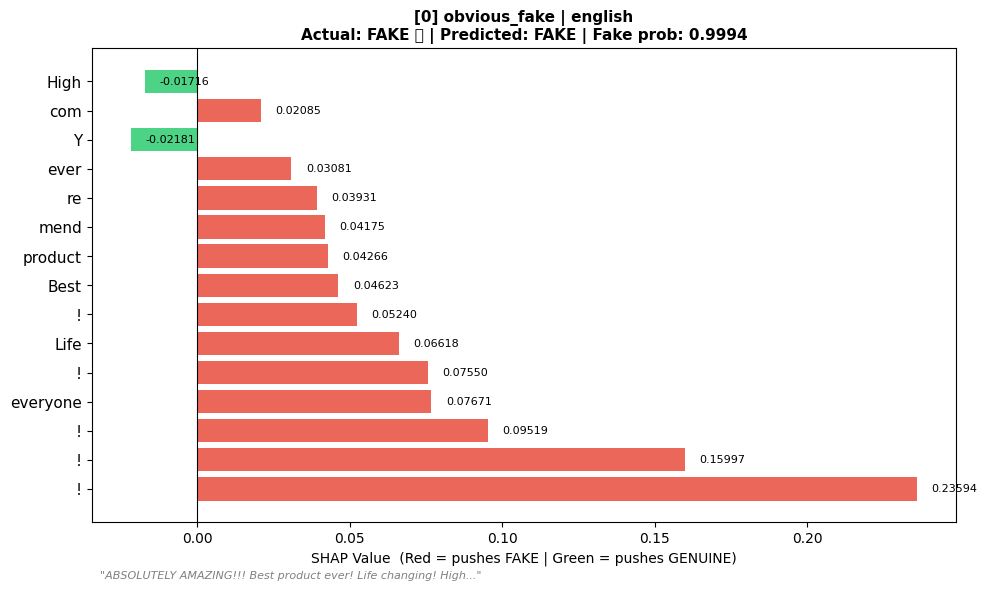

✅ [0] Saved → ../results/figures/shap/00_FAKE_obvious_fake.png


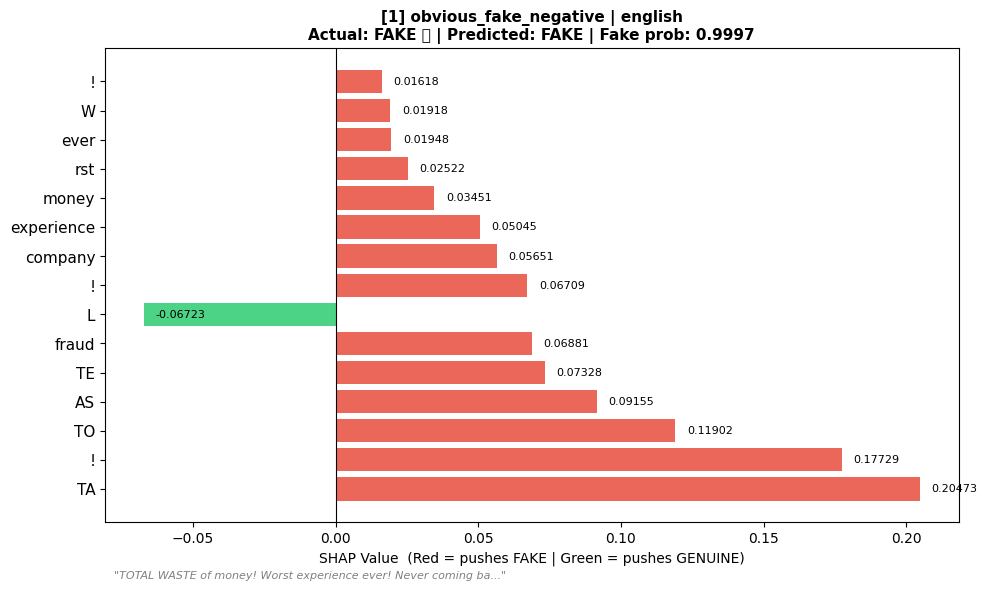

✅ [1] Saved → ../results/figures/shap/01_FAKE_obvious_fake.png


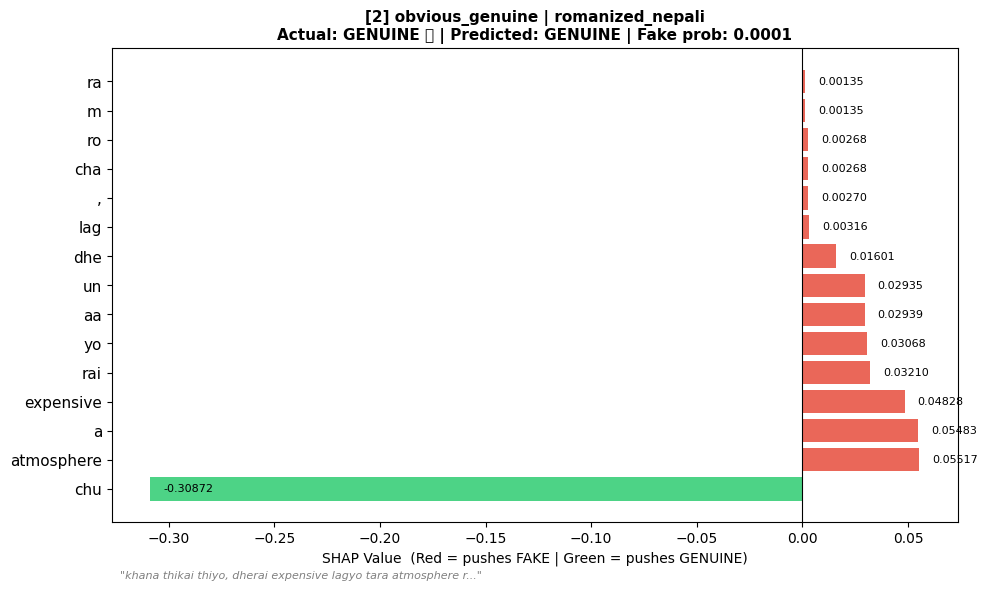

✅ [2] Saved → ../results/figures/shap/02_GENUINE_obvious_genu.png


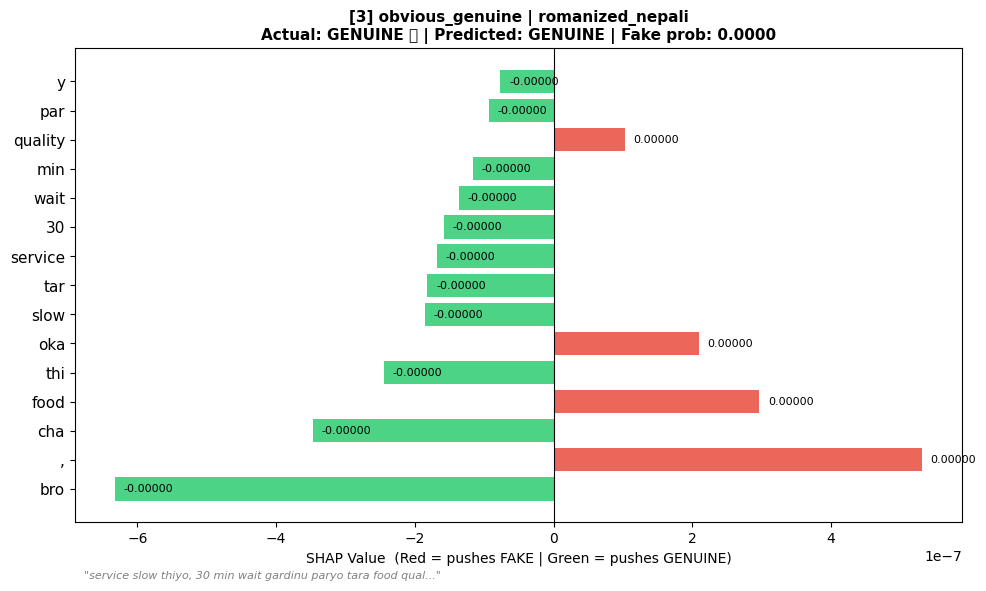

✅ [3] Saved → ../results/figures/shap/03_GENUINE_obvious_genu.png


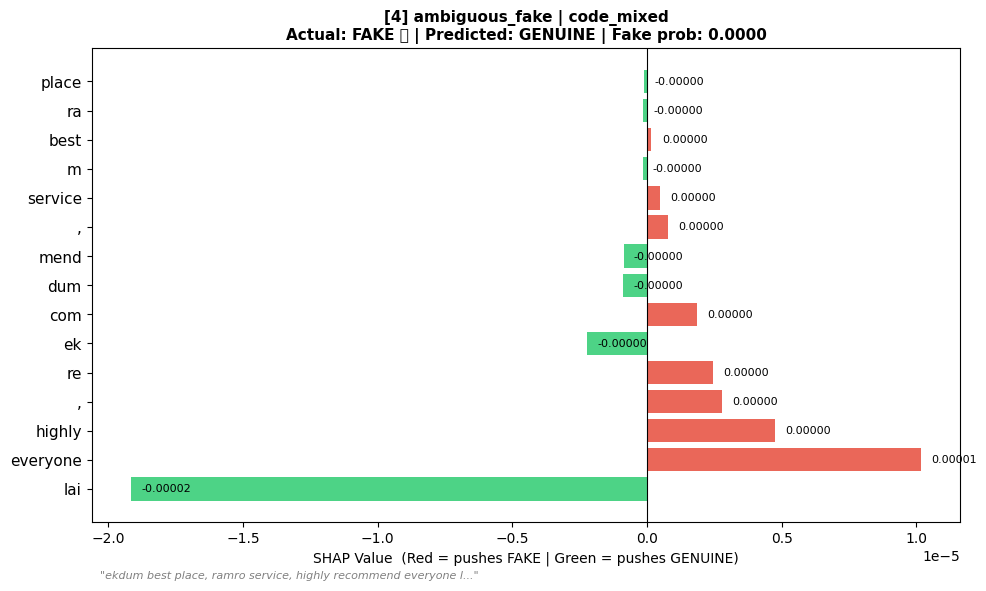

✅ [4] Saved → ../results/figures/shap/04_FAKE_ambiguous_fa.png


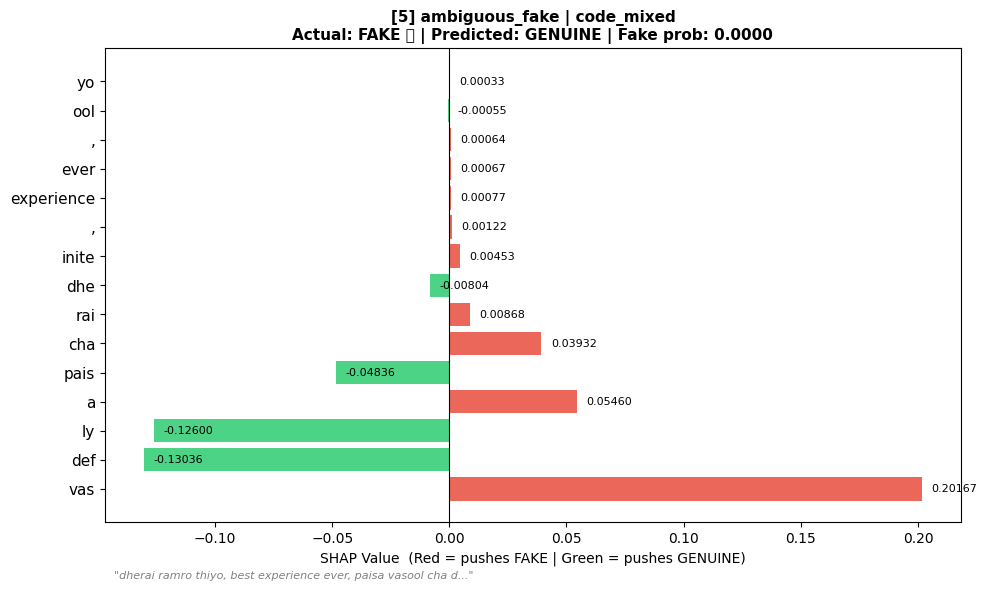

✅ [5] Saved → ../results/figures/shap/05_FAKE_ambiguous_fa.png


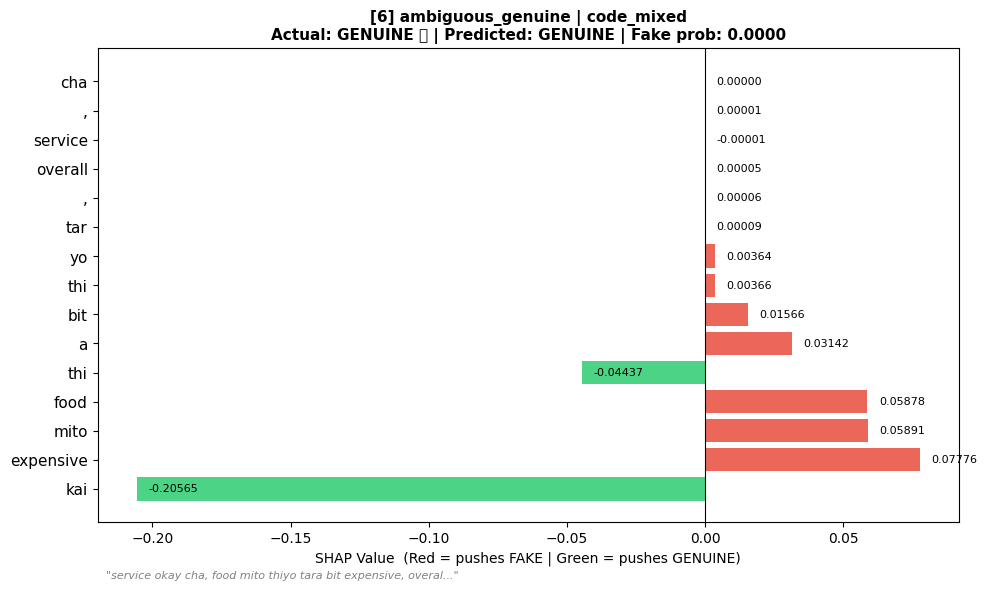

✅ [6] Saved → ../results/figures/shap/06_GENUINE_ambiguous_ge.png


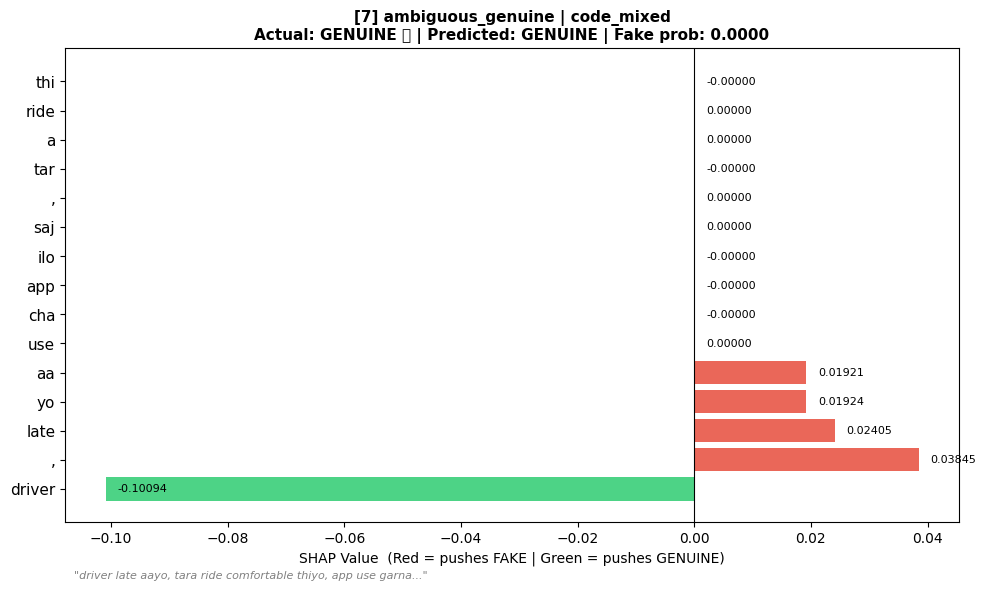

✅ [7] Saved → ../results/figures/shap/07_GENUINE_ambiguous_ge.png


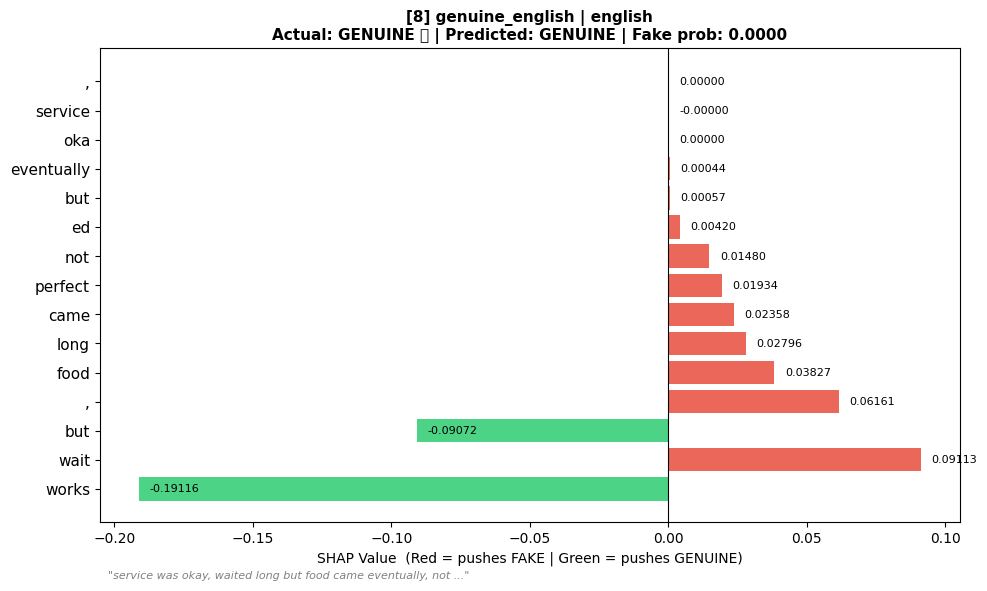

✅ [8] Saved → ../results/figures/shap/08_GENUINE_genuine_engl.png


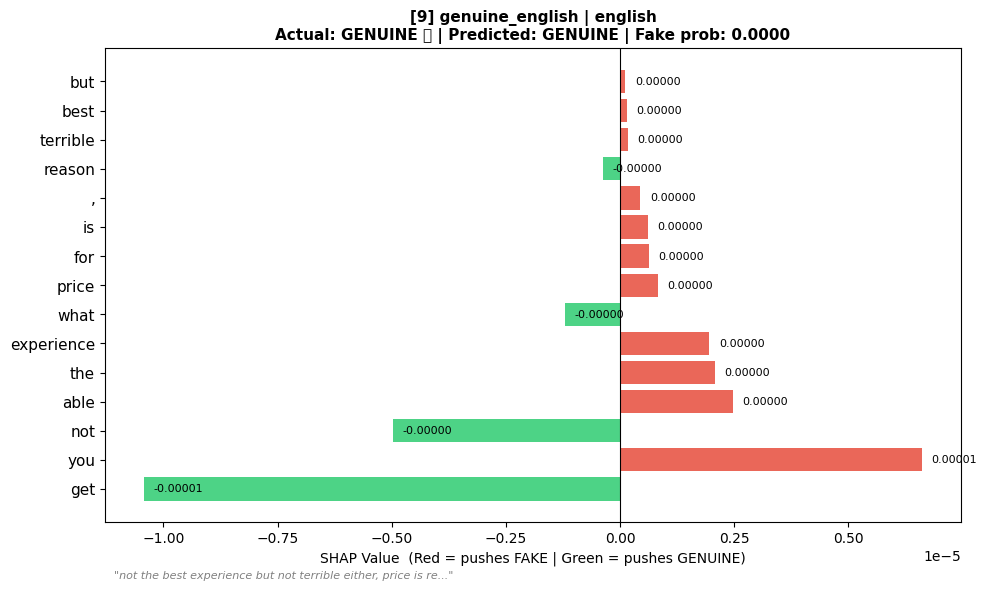

✅ [9] Saved → ../results/figures/shap/09_GENUINE_genuine_engl.png


In [79]:
# ══════════════════════════════════════════════════════════════
# VISUALIZATION 1 — TOKEN BAR PLOTS (PER SAMPLE)
# ══════════════════════════════════════════════════════════════
print("\n📊 Generating per-sample token importance plots...")

for idx, s in enumerate(samples):
    label = "FAKE"    if s["label"]==1 else "GENUINE"
    prob  = all_probs[idx]
    pred  = "FAKE"    if prob[1] > 0.5 else "GENUINE"
    ok    = "✅" if label == pred else "❌"

    top_tokens = get_top_tokens(idx, shap_values, top_n=15)
    if not top_tokens:
        continue

    t_names = [t for t, _ in top_tokens]
    t_vals  = [v for _, v in top_tokens]
    colors  = [
        "#E74C3C" if v > 0 else "#2ECC71"
        for v in t_vals
    ]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(
        range(len(t_names)), t_vals,
        color=colors, alpha=0.85
    )
    ax.set_yticks(range(len(t_names)))
    ax.set_yticklabels(t_names, fontsize=11)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_xlabel(
        "SHAP Value  "
        "(Red = pushes FAKE | Green = pushes GENUINE)"
    )
    ax.set_title(
        f"[{idx}] {s['type']} | {s['lang']}\n"
        f"Actual: {label} {ok} | "
        f"Predicted: {pred} | "
        f"Fake prob: {prob[1]:.4f}",
        fontsize=11, fontweight="bold"
    )

    # Value labels
    max_val = max(abs(v) for v in t_vals) if t_vals else 1
    for bar, val in zip(bars, t_vals):
        ax.text(
            bar.get_width() + max_val * 0.02,
            bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va="center", fontsize=8
        )

    # Text preview
    preview = s["text"][:60] + "..."
    ax.text(
        0.01, -0.12, f'"{preview}"',
        transform=ax.transAxes,
        fontsize=8, style="italic", color="gray"
    )

    plt.tight_layout()
    save_path = (
        f"../results/figures/shap/"
        f"{idx:02d}_{label}_{s['type'][:12]}.png"
    )
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ [{idx}] Saved → {save_path}")


📊 Generating global importance plot...


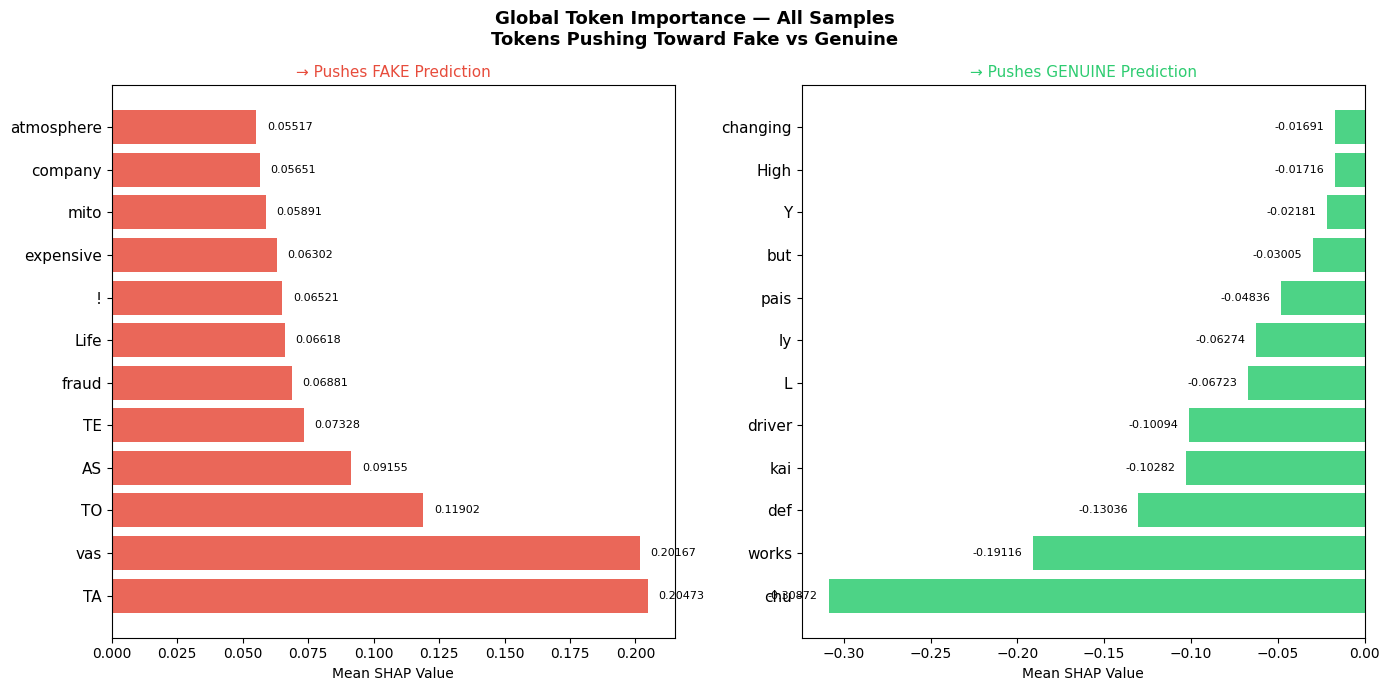

✅ Saved → global_token_importance.png


In [80]:
# ══════════════════════════════════════════════════════════════
# VISUALIZATION 2 — GLOBAL TOKEN IMPORTANCE
# ══════════════════════════════════════════════════════════════
print("\n📊 Generating global importance plot...")

token_imp_all = {}
for idx in range(len(samples)):
    tokens = shap_values[idx].data
    values = shap_values[idx].values[:, 1]
    for t, v in zip(tokens, values):
        t = t.strip()
        if t and t not in SPECIAL_TOKENS:
            if t not in token_imp_all:
                token_imp_all[t] = []
            token_imp_all[t].append(v)

avg_global = {
    t: np.mean(vals)
    for t, vals in token_imp_all.items()
}

top_fake = sorted(
    {t:v for t,v in avg_global.items() if v > 0}.items(),
    key=lambda x: x[1], reverse=True
)[:12]

top_genuine = sorted(
    {t:v for t,v in avg_global.items() if v < 0}.items(),
    key=lambda x: x[1]
)[:12]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "Global Token Importance — All Samples\n"
    "Tokens Pushing Toward Fake vs Genuine",
    fontsize=13, fontweight="bold"
)

# Fake tokens
t_f = [t for t,_ in top_fake]
v_f = [v for _,v in top_fake]
bars1 = ax1.barh(
    range(len(t_f)), v_f, color="#E74C3C", alpha=0.85
)
ax1.set_yticks(range(len(t_f)))
ax1.set_yticklabels(t_f, fontsize=11)
ax1.set_title("→ Pushes FAKE Prediction",
              fontsize=11, color="#E74C3C")
ax1.set_xlabel("Mean SHAP Value")
ax1.axvline(x=0, color="black", linewidth=0.5)
for bar, val in zip(bars1, v_f):
    ax1.text(bar.get_width() + max(v_f)*0.02, 
             bar.get_y() + bar.get_height()/2,
             f"{val:.5f}", va="center", fontsize=8)

# Genuine tokens
t_g = [t for t,_ in top_genuine]
v_g = [v for _,v in top_genuine]
bars2 = ax2.barh(
    range(len(t_g)), v_g, color="#2ECC71", alpha=0.85
)
ax2.set_yticks(range(len(t_g)))
ax2.set_yticklabels(t_g, fontsize=11)
ax2.set_title("→ Pushes GENUINE Prediction",
              fontsize=11, color="#2ECC71")
ax2.set_xlabel("Mean SHAP Value")
ax2.axvline(x=0, color="black", linewidth=0.5)
for bar, val in zip(bars2, v_g):
    ax2.text(bar.get_width() - abs(min(v_g))*0.02,
             bar.get_y() + bar.get_height()/2,
             f"{val:.5f}", va="center",
             ha="right", fontsize=8)

plt.tight_layout()
plt.savefig(
    "../results/figures/shap/global_token_importance.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Saved → global_token_importance.png")


📊 Generating language-wise comparison plot...


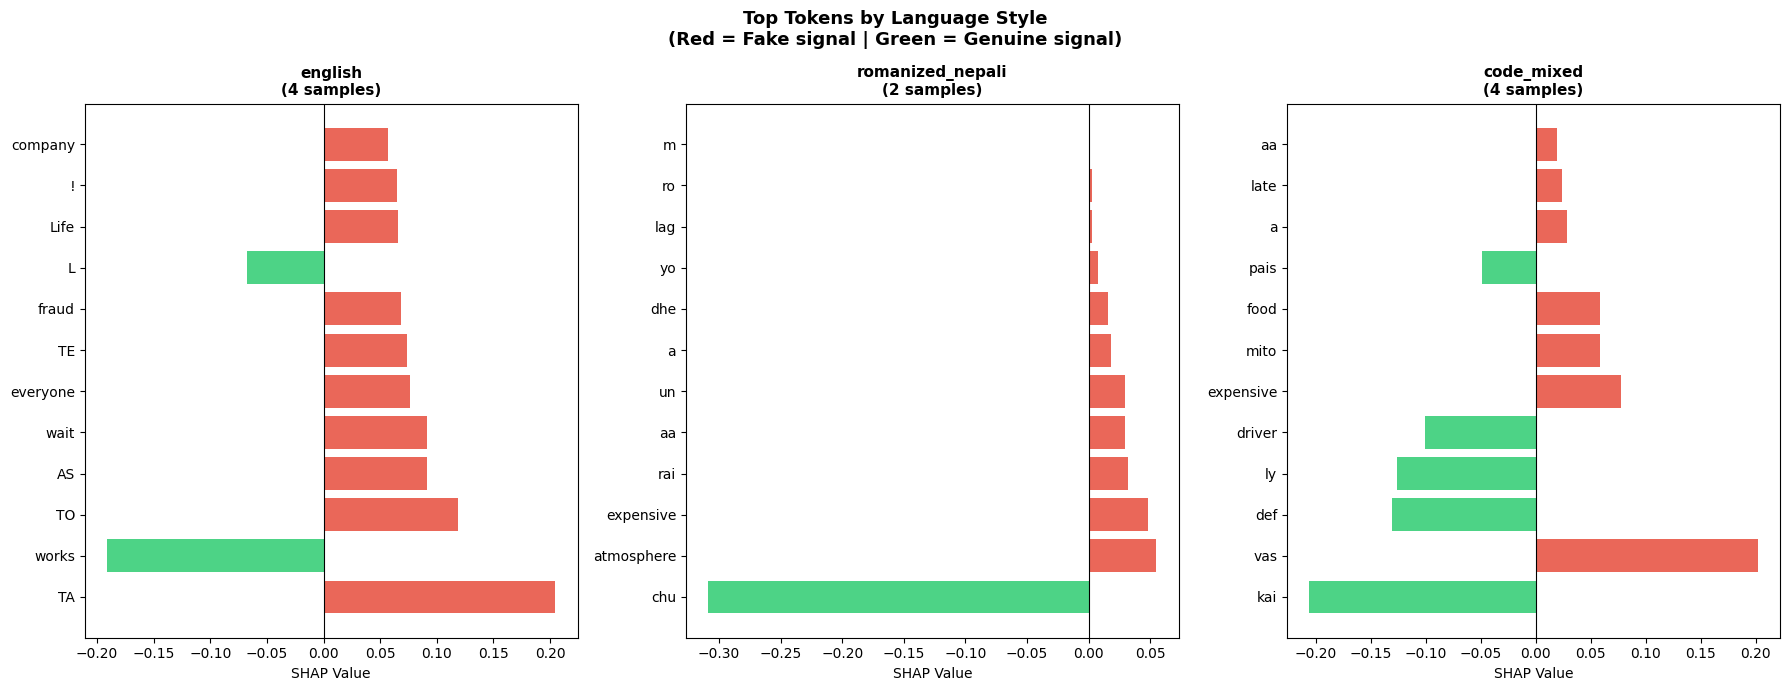

✅ Saved → language_comparison.png


In [81]:
# ══════════════════════════════════════════════════════════════
# VISUALIZATION 3 — LANGUAGE-WISE COMPARISON
# ══════════════════════════════════════════════════════════════
print("\n📊 Generating language-wise comparison plot...")

languages = ["english", "romanized_nepali", "code_mixed"]
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    "Top Tokens by Language Style\n"
    "(Red = Fake signal | Green = Genuine signal)",
    fontsize=13, fontweight="bold"
)

for ax, lang in zip(axes, languages):
    lang_indices = [
        i for i, s in enumerate(samples)
        if s["lang"] == lang
    ]

    if not lang_indices:
        ax.set_title(f"{lang}\n(no samples)")
        continue

    # Collect tokens for this language
    token_imp_lang = {}
    for idx in lang_indices:
        tokens = shap_values[idx].data
        values = shap_values[idx].values[:, 1]
        for t, v in zip(tokens, values):
            t = t.strip()
            if t and t not in SPECIAL_TOKENS:
                if t not in token_imp_lang:
                    token_imp_lang[t] = []
                token_imp_lang[t].append(v)

    avg_lang = {
        t: np.mean(vals)
        for t, vals in token_imp_lang.items()
    }

    sorted_lang = sorted(
        avg_lang.items(),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:12]

    t_names = [t for t, _ in sorted_lang]
    t_vals  = [v for _, v in sorted_lang]
    colors  = [
        "#E74C3C" if v > 0 else "#2ECC71"
        for v in t_vals
    ]

    ax.barh(range(len(t_names)), t_vals,
            color=colors, alpha=0.85)
    ax.set_yticks(range(len(t_names)))
    ax.set_yticklabels(t_names, fontsize=10)
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_title(
        f"{lang}\n({len(lang_indices)} samples)",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("SHAP Value")

plt.tight_layout()
plt.savefig(
    "../results/figures/shap/language_comparison.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Saved → language_comparison.png")


📊 Generating fake vs genuine pattern comparison...


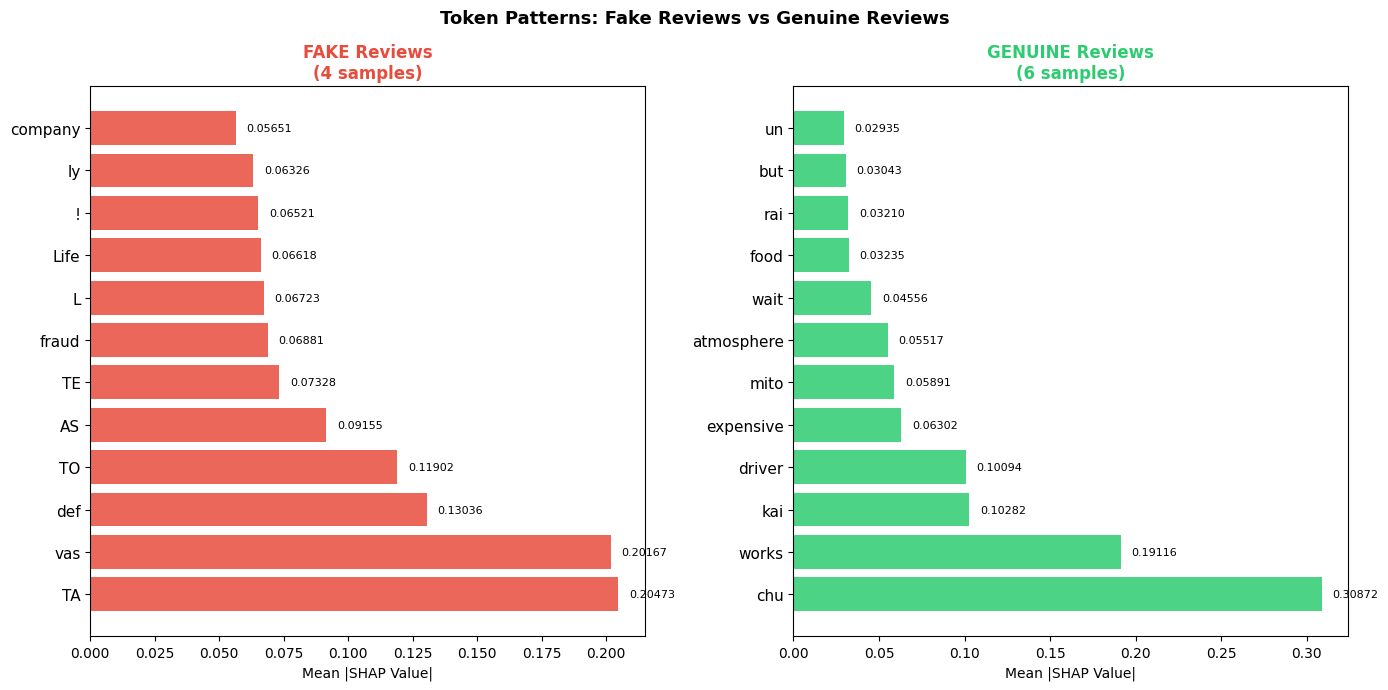

✅ Saved → fake_vs_genuine_patterns.png


In [82]:
# ══════════════════════════════════════════════════════════════
# VISUALIZATION 4 — FAKE vs GENUINE PATTERN COMPARISON
# ══════════════════════════════════════════════════════════════
print("\n📊 Generating fake vs genuine pattern comparison...")

fake_indices    = [i for i,s in enumerate(samples)
                   if s["label"]==1]
genuine_indices = [i for i,s in enumerate(samples)
                   if s["label"]==0]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "Token Patterns: Fake Reviews vs Genuine Reviews",
    fontsize=13, fontweight="bold"
)

for ax, indices, title, color in zip(
    axes,
    [fake_indices, genuine_indices],
    ["FAKE Reviews", "GENUINE Reviews"],
    ["#E74C3C", "#2ECC71"]
):
    token_imp = {}
    for idx in indices:
        tokens = shap_values[idx].data
        values = shap_values[idx].values[:, 1]
        for t, v in zip(tokens, values):
            t = t.strip()
            if t and t not in SPECIAL_TOKENS:
                if t not in token_imp:
                    token_imp[t] = []
                token_imp[t].append(abs(v))

    avg_imp = {
        t: np.mean(vals)
        for t, vals in token_imp.items()
    }

    sorted_imp = sorted(
        avg_imp.items(),
        key=lambda x: x[1], reverse=True
    )[:12]

    t_names = [t for t, _ in sorted_imp]
    t_vals  = [v for _, v in sorted_imp]

    bars = ax.barh(
        range(len(t_names)), t_vals,
        color=color, alpha=0.85
    )
    ax.set_yticks(range(len(t_names)))
    ax.set_yticklabels(t_names, fontsize=11)
    ax.set_title(
        f"{title}\n({len(indices)} samples)",
        fontsize=12, fontweight="bold", color=color
    )
    ax.set_xlabel("Mean |SHAP Value|")

    for bar, val in zip(bars, t_vals):
        ax.text(
            bar.get_width() + max(t_vals)*0.02,
            bar.get_y() + bar.get_height()/2,
            f"{val:.5f}", va="center", fontsize=8
        )

plt.tight_layout()
plt.savefig(
    "../results/figures/shap/fake_vs_genuine_patterns.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Saved → fake_vs_genuine_patterns.png")

In [83]:

# ══════════════════════════════════════════════════════════════
# VISUALIZATION 5 — SHAP TEXT PLOTS (INLINE HIGHLIGHTS)
# ══════════════════════════════════════════════════════════════
print("\n📊 Generating inline text highlight plots...")

for idx, s in enumerate(samples):
    label = "FAKE" if s["label"]==1 else "GENUINE"
    prob  = all_probs[idx]

    print(f"\n[{idx}] {s['type']} | {s['lang']} | "
          f"Actual:{label} | FakeProb:{prob[1]:.4f}")
    print(f"Text: {s['text']}")

    try:
        shap.plots.text(
            shap_values[idx, :, 1],
            display=True
        )
    except Exception as e:
        print(f"  ⚠️ Text plot failed: {e}")


📊 Generating inline text highlight plots...

[0] obvious_fake | english | Actual:FAKE | FakeProb:0.9994
Text: ABSOLUTELY AMAZING!!! Best product ever! Life changing! Highly recommend to everyone!!!



[1] obvious_fake_negative | english | Actual:FAKE | FakeProb:0.9997
Text: TOTAL WASTE of money! Worst experience ever! Never coming back! Criminal fraud company!!!



[2] obvious_genuine | romanized_nepali | Actual:GENUINE | FakeProb:0.0001
Text: khana thikai thiyo, dherai expensive lagyo tara atmosphere ramro cha, feri aaunchu



[3] obvious_genuine | romanized_nepali | Actual:GENUINE | FakeProb:0.0000
Text: service slow thiyo, 30 min wait gardinu paryo tara food quality okay cha bro



[4] ambiguous_fake | code_mixed | Actual:FAKE | FakeProb:0.0000
Text: ekdum best place, ramro service, highly recommend everyone lai



[5] ambiguous_fake | code_mixed | Actual:FAKE | FakeProb:0.0000
Text: dherai ramro thiyo, best experience ever, paisa vasool cha definitely



[6] ambiguous_genuine | code_mixed | Actual:GENUINE | FakeProb:0.0000
Text: service okay cha, food mito thiyo tara bit expensive, overall thikai



[7] ambiguous_genuine | code_mixed | Actual:GENUINE | FakeProb:0.0000
Text: driver late aayo, tara ride comfortable thiyo, app use garna sajilo cha



[8] genuine_english | english | Actual:GENUINE | FakeProb:0.0000
Text: service was okay, waited long but food came eventually, not perfect but works



[9] genuine_english | english | Actual:GENUINE | FakeProb:0.0000
Text: not the best experience but not terrible either, price is reasonable for what you get


In [84]:
# ══════════════════════════════════════════════════════════════
#  SAVE SHAP FINDINGS
# ══════════════════════════════════════════════════════════════
shap_findings = {
    "top_fake_tokens": [
        {"token": t, "mean_shap": round(v, 6)}
        for t, v in top_fake
    ],
    "top_genuine_tokens": [
        {"token": t, "mean_shap": round(v, 6)}
        for t, v in top_genuine
    ],
    "samples_analyzed": len(samples),
    "model_used":       "mBERT_finetuned",
    "note": (
        "Borderline samples unavailable from test set "
        "due to near-perfect model confidence on synthetic "
        "data. Manually crafted ambiguous samples used."
    )
}

with open("../results/metrics/shap_findings.json", "w") as f:
    json.dump(shap_findings, f, indent=2, ensure_ascii=False)


In [85]:
# ══════════════════════════════════════════════════════════════
# PRINT KEY FINDINGS
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  SHAP KEY FINDINGS")
print("="*60)

print("\n🔴 Top tokens pushing → FAKE:")
for t, v in top_fake[:8]:
    print(f"   '{t}'  →  {v:+.6f}")

print("\n🟢 Top tokens pushing → GENUINE:")
for t, v in top_genuine[:8]:
    print(f"   '{t}'  →  {v:+.6f}")

print("\n📊 Plots saved:")
plots = [
    "Per-sample token bars  → shap/XX_LABEL_type.png",
    "Global importance      → shap/global_token_importance.png",
    "Language comparison    → shap/language_comparison.png",
    "Fake vs genuine        → shap/fake_vs_genuine_patterns.png",
    "Text highlights        → displayed inline",
]
for p in plots:
    print(f"   ✅ {p}")

print("\n🎯 XAI/SHAP notebook complete!")


  SHAP KEY FINDINGS

🔴 Top tokens pushing → FAKE:
   'TA'  →  +0.204728
   'vas'  →  +0.201669
   'TO'  →  +0.119019
   'AS'  →  +0.091548
   'TE'  →  +0.073282
   'fraud'  →  +0.068807
   'Life'  →  +0.066176
   '!'  →  +0.065209

🟢 Top tokens pushing → GENUINE:
   'chu'  →  -0.308720
   'works'  →  -0.191161
   'def'  →  -0.130360
   'kai'  →  -0.102824
   'driver'  →  -0.100936
   'L'  →  -0.067229
   'ly'  →  -0.062737
   'pais'  →  -0.048359

📊 Plots saved:
   ✅ Per-sample token bars  → shap/XX_LABEL_type.png
   ✅ Global importance      → shap/global_token_importance.png
   ✅ Language comparison    → shap/language_comparison.png
   ✅ Fake vs genuine        → shap/fake_vs_genuine_patterns.png
   ✅ Text highlights        → displayed inline

🎯 XAI/SHAP notebook complete!
